Training Optimal Transport Domain Adaptation network...
Epoch 10/40 | Loss: 2.2088 (Cls: 2.1752, OT: 0.1119)
Epoch 20/40 | Loss: 1.8923 (Cls: 1.7818, OT: 0.3684)
Epoch 30/40 | Loss: 1.6133 (Cls: 1.4426, OT: 0.5690)
Epoch 40/40 | Loss: 1.3158 (Cls: 1.1082, OT: 0.6920)

EVALUATION ON TEST SETS
Accuracy on Source (Clean MNIST) : 67.00%
Accuracy on Target (Noisy MNIST)  : 19.00%


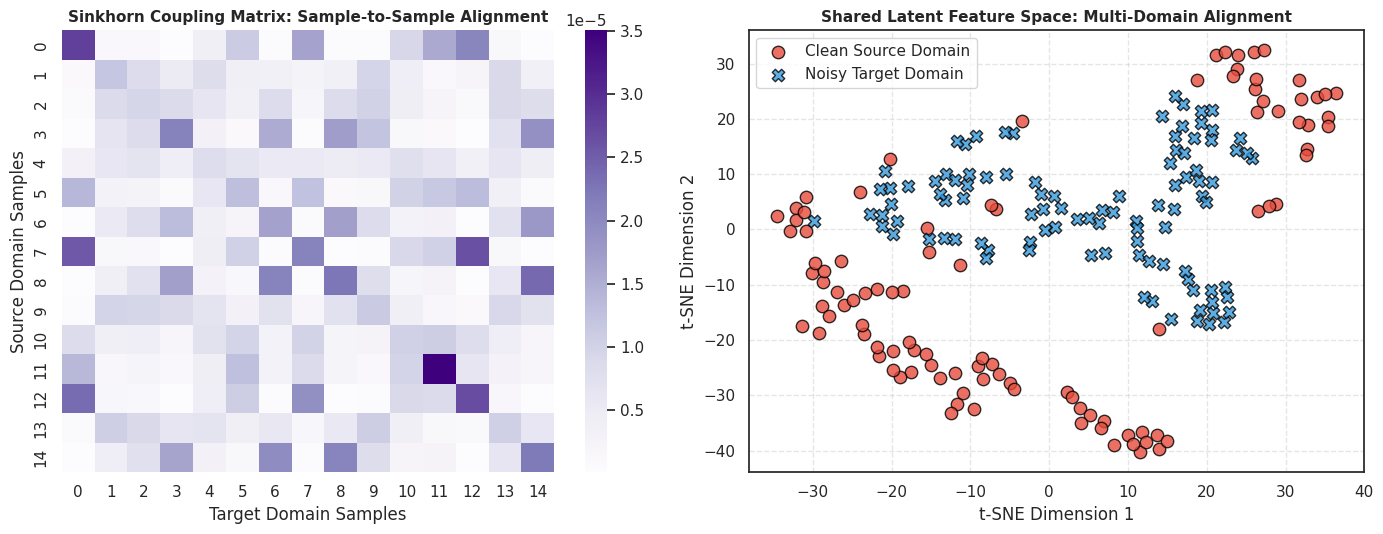

In [ ]:

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import urllib.request  # download files
import scipy.io  # load mat files
import numpy as np  # fast math
import tensorflow as tf  # deep learning
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling
from sklearn.manifold import TSNE  # visual clustering

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # hide tf logs
warnings.filterwarnings('ignore')  # silence warnings

SEED = 42  # standard seed
np.random.seed(SEED)  # seed numpy
tf.random.set_seed(SEED)  # seed tensorflow

# ==========================================
# 1. Sinkhorn Loss (Optimal Transport)
# ==========================================

# Sinkhorn Loss: Computes optimal transport cost between source and target features via iterative matrix scaling - measures Wasserstein distance for domain alignment. Returns transport plan P and cost.
def sinkhorn_loss(source_features, target_features, epsilon=0.1, n_iters=15):
    n = tf.shape(source_features)[0]  # source size
    m = tf.shape(target_features)[0]  # target size

    # Compute pairwise squared Euclidean distance matrix C
    x_col = tf.expand_dims(source_features, 1)  # shape (n, 1, dim)
    y_row = tf.expand_dims(target_features, 0)  # shape (1, m, dim)
    C = tf.reduce_sum(tf.square(x_col - y_row), axis=-1)  # distance calculations

    # Compute Gibbs kernel matrix K
    K = tf.exp(-C / epsilon)  # exponentiate costs

    # Uniform marginal distributions mu and nu
    mu = tf.ones((n, 1), dtype=tf.float32) / tf.cast(n, tf.float32)  # source marginals
    nu = tf.ones((m, 1), dtype=tf.float32) / tf.cast(m, tf.float32)  # target marginals

    # Initialize scaling scaling vector v
    v = tf.ones((m, 1), dtype=tf.float32)  # scaling factors

    # Sinkhorn iterative matrix scaling
    for _ in range(n_iters):
        u = mu / (tf.matmul(K, v) + 1e-8)  # update u
        v = nu / (tf.matmul(K, u, transpose_a=True) + 1e-8)  # update v

    # Calculate coupling transport plan matrix P
    P = u * K * tf.transpose(v)  # optimal pairing plan
    ot_loss = tf.reduce_sum(P * C)  # total transport cost
    return ot_loss, P  # return variables

# ==========================================
# 2. Get / Generate Shifted Datasets
# ==========================================

# prepare_real_datasets: Loads MNIST as source domain (clean), creates target domain by adding noise and scaling - simulates domain shift for adaptation. Returns both domains with labels.
def prepare_real_datasets(num_samples=400):
    try:
        # Fetch MNIST source domain images
        (x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.mnist.load_data()  # load data
        x_tr, y_tr = x_tr[:num_samples], y_tr[:num_samples]  # slice train
        x_te, y_te = x_te[:num_samples//4], y_te[:num_samples//4]  # slice test

        # Resize to 32x32 to match Conv2D inputs
        x_tr_resized = tf.image.resize(np.expand_dims(x_tr, -1), [32, 32]).numpy()  # resize train
        x_te_resized = tf.image.resize(np.expand_dims(x_te, -1), [32, 32]).numpy()  # resize test

        # Stack to 3 channels (RGB)
        x_src_tr = np.repeat(x_tr_resized, 3, axis=-1) / 255.0  # normalize train
        x_src_te = np.repeat(x_te_resized, 3, axis=-1) / 255.0  # normalize test

        # Create corrupted target domain to simulate Street View (SVHN) noise shift
        noise_train = np.random.normal(loc=0.3, scale=0.2, size=x_src_tr.shape)  # build noise
        noise_test = np.random.normal(loc=0.3, scale=0.2, size=x_src_te.shape)  # build noise
        x_tgt_tr = np.clip(x_src_tr * 0.5 + noise_train, 0.0, 1.0).astype(np.float32)  # target train
        x_tgt_te = np.clip(x_src_te * 0.5 + noise_test, 0.0, 1.0).astype(np.float32)  # target test

        return (x_src_tr, y_tr), (x_src_te, y_te), (x_tgt_tr, y_tr), (x_tgt_te, y_te)  # return datasets
    except Exception as e:
        print(f"Error loading datasets: {e}. Generating synthetic fallback...")  # log error
        x_src_tr = np.random.randn(100, 32, 32, 3).astype(np.float32)  # fake train
        y_src_tr = np.random.randint(0, 10, 100).astype(np.int32)  # fake labels
        x_src_te = np.random.randn(25, 32, 32, 3).astype(np.float32)  # fake test
        y_src_te = np.random.randint(0, 10, 25).astype(np.int32)  # fake labels

        x_tgt_tr = np.clip(x_src_tr + 0.5, 0.0, 1.0)  # fake target train
        x_tgt_te = np.clip(x_src_te + 0.5, 0.0, 1.0)  # fake target test
        return (x_src_tr, y_src_tr), (x_src_te, y_src_te), (x_tgt_tr, y_src_tr), (x_tgt_te, y_src_te)  # return datasets

# Load datasets
(x_src_tr, y_src_tr), (x_src_te, y_src_te), (x_tgt_tr, y_tgt_tr), (x_tgt_te, y_tgt_te) = prepare_real_datasets()

# ==========================================
# 3. Optimal Transport Model Architecture
# ==========================================

# OptimalTransportDA: CNN feature extractor (Conv→BN→Pool x3, 128-dim GAP) + classifier (64→10 softmax). Returns both logits and features for classification + OT alignment.
class OptimalTransportDA(tf.keras.Model):
    def __init__(self):
        super().__init__()
        # Deep convolutional feature extractor (fuses features into a shared representation)
        self.feature_extractor = tf.keras.Sequential([
            tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32, 32, 3)),  # conv 1
            tf.keras.layers.BatchNormalization(),  # normalize 1
            tf.keras.layers.MaxPooling2D(),  # pool 1
            tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),  # conv 2
            tf.keras.layers.BatchNormalization(),  # normalize 2
            tf.keras.layers.MaxPooling2D(),  # pool 2
            tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),  # conv 3
            tf.keras.layers.BatchNormalization(),  # normalize 3
            tf.keras.layers.GlobalAveragePooling2D()  # pooling head (128 dimensions)
        ])
        # Classifier mapping features to 10 digit classes
        self.classifier = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu'),  # hidden dense
            tf.keras.layers.Dense(10, activation='softmax')  # softmax classifier
        ])

    def call(self, x):
        feats = self.feature_extractor(x)  # extract features
        logits = self.classifier(feats)  # predict labels
        return logits, feats  # return both

# Initialize network and optimizers
model = OptimalTransportDA()  # load network
optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)  # adam optimizer
class_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()  # cross-entropy loss

# ==========================================
# 4. Training Loop
# ==========================================

print("Training Optimal Transport Domain Adaptation network...")  # status log
for epoch in range(40):  # epoch iterations
    with tf.GradientTape() as tape:  # track gradients
        logits_src, feats_src = model(x_src_tr)  # source forward pass
        logits_tgt, feats_tgt = model(x_tgt_tr)  # target forward pass

        # Calculate standard classification loss on Source labels
        cls_loss = class_loss_fn(y_src_tr, logits_src)  # label loss

        # Calculate Sinkhorn transport distance to align Target features with Source features
        ot_loss, P = sinkhorn_loss(feats_src, feats_tgt, epsilon=0.5)  # OT loss

        # Total combined loss objective
        total_loss = cls_loss + 0.3 * ot_loss  # scaled loss sum

    grads = tape.gradient(total_loss, model.trainable_variables)  # calculate gradients
    optimizer.apply_gradients(zip(grads, model.trainable_variables))  # update weights

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/40 | Loss: {total_loss.numpy():.4f} (Cls: {cls_loss.numpy():.4f}, OT: {ot_loss.numpy():.4f})")

# ==========================================
# Evaluation & Metric Summary
# ==========================================

logits_src_te, _ = model(x_src_te)  # predict clean test
logits_tgt_te, _ = model(x_tgt_te)  # predict noisy test

acc_src = np.mean(np.argmax(logits_src_te.numpy(), axis=1) == y_src_te)  # source score
acc_tgt = np.mean(np.argmax(logits_tgt_te.numpy(), axis=1) == y_tgt_te)  # target score

print("\n=====================================")
print("EVALUATION ON TEST SETS")
print("=====================================")
print(f"Accuracy on Source (Clean MNIST) : {acc_src * 100:.2f}%")
print(f"Accuracy on Target (Noisy MNIST)  : {acc_tgt * 100:.2f}%")
print("=====================================")

# ==========================================
# Visualizing Domain Shift Aligned Space
# ==========================================

sns.set_theme(style="white")  # set theme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))  # double canvas

# Left plot: The Sinkhorn Transport Coupling Plan Heatmap
sns.heatmap(P.numpy()[:15, :15], annot=False, cmap='Purples', ax=ax1, cbar=True)  # draw coupling heatmap
ax1.set_xlabel('Target Domain Samples')
ax1.set_ylabel('Source Domain Samples')
ax1.set_title('Sinkhorn Coupling Matrix: Sample-to-Sample Alignment', fontsize=11, fontweight='bold')

# Right plot: 2D t-SNE projection of Aligned Latent Features
_, final_feats_src = model(x_src_te)  # source embeddings
_, final_feats_tgt = model(x_tgt_te)  # target embeddings

# Concatenate embeddings for joint dimensional reduction
combined_feats = np.concatenate([final_feats_src.numpy(), final_feats_tgt.numpy()], axis=0)  # fuse arrays
tsne = TSNE(n_components=2, perplexity=10, random_state=SEED)  # tsne inst
reduced_feats = tsne.fit_transform(combined_feats)  # run projection

# Split embeddings back into source and target dimensions
n_samples = len(x_src_te)  # offset split index
src_tsne = reduced_feats[:n_samples]  # source tsne coord
tgt_tsne = reduced_feats[n_samples:]  # target tsne coord

ax2.scatter(src_tsne[:, 0], src_tsne[:, 1], color='#e74c3c', alpha=0.8, edgecolors='black', label='Clean Source Domain', s=80)  # source scatter
ax2.scatter(tgt_tsne[:, 0], tgt_tsne[:, 1], color='#3498db', alpha=0.8, edgecolors='black', marker='X', label='Noisy Target Domain', s=80)  # target scatter
ax2.set_xlabel('t-SNE Dimension 1')
ax2.set_ylabel('t-SNE Dimension 2')
ax2.set_title('Shared Latent Feature Space: Multi-Domain Alignment', fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # fit layout
plt.show()  # display plots